## Creating a list of mileposts of interest

In [ ]:
# Adapted from : 
"""
https://stackoverflow.com/questions/75041443/plot-milepost-along-coastline-in-python

Improved by : 
Steps to generate the .SHP coastline file : 
1 - Get natural earth shape file (i.e. from https://www.naturalearthdata.com/downloads/10m-physical-vectors/)
2 - Make sure to remove islands (polygons) that do not fit the "coastline"
3 - Convert polygon to line (on a new layer)
4 - Add Polygons on another layer (ex: a scratch layer). Edit new polygon shapes (using vertices) to "mask" unwanted coastlines. 
5 - Boolean cut and save the output on its own shapefile.
"""

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from shapely.geometry import LineString

In [2]:
# Directory of the files : 
filepath = r'C:\YOUR\OWN\PATH\TO\SHAPEFILES'

# Read the shapefiles : 
cl_gdf = gpd.read_file(filepath+"lines_110mv4.shp")

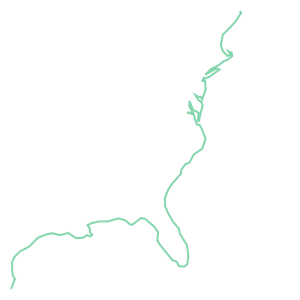

In [3]:
# project data from geographic crs so we have meters for interpolation below, vs degrees
cl_gdf = cl_gdf.to_crs(9311)

# get shapely ls from gdf
coastline = cl_gdf.iloc[0].geometry
# Quick overview of the coastline : 
coastline

In [4]:
interval = 160934 # approx 100 miles in meters
interval_arr = np.arange(0, coastline.length, interval )
points = [coastline.interpolate(d) for d in interval_arr] + [coastline.boundary.geoms[1]]

# create gdf from our list of interpolated Shapely points
points_gdf = gpd.GeoDataFrame(geometry=points, crs=9311)
print(f'The number of mileposts generated is : {points_gdf.shape[0]}')

# transform crs to wgs84 for plotting
points_gdf = points_gdf.to_crs(4326)

# add Lat and Long cols from geometry for plotting
points_gdf['Lat'] = (points_gdf['geometry'].apply(lambda geom: np.max([coord[1] for coord in geom.coords])))
points_gdf['Long'] = (points_gdf['geometry'].apply(lambda geom: np.max([coord[0] for coord in geom.coords])))
points_gdf = points_gdf.drop(columns = ['geometry'])
# First lat : 45 and final : 25 (as per boolean cut on the .SHP file)
display(points_gdf)

The number of mileposts generated is : 44


,Lat,Long
0,45.000000,-67.064909
1,44.181844,-68.465176
2,43.548081,-70.237050
3,42.248884,-70.771053
4,41.948590,-69.919435
5,41.425572,-71.416143
6,41.081077,-73.281998
7,41.115589,-72.273663
8,40.630110,-73.393453
9,40.150574,-74.046665


In [5]:
# Add custom points as needed : 
Additional_pts = pd.DataFrame([(44.651070,-63.582687)], columns =['Lat','Long'] )
display(Additional_pts)
points_gdf = pd.concat([Additional_pts,points_gdf], ignore_index = True)
display(points_gdf)

,Lat,Long
0,44.65107,-63.582687


,Lat,Long
0,44.651070,-63.582687
1,45.000000,-67.064909
2,44.181844,-68.465176
3,43.548081,-70.237050
4,42.248884,-70.771053
5,41.948590,-69.919435
6,41.425572,-71.416143
7,41.081077,-73.281998
8,41.115589,-72.273663
9,40.630110,-73.393453


In [6]:
# Re-order the index labels :
points_gdf= points_gdf.reindex(index=points_gdf.index[::-1]).reset_index(drop=True)
display(points_gdf)

,Lat,Long
0,25.000000,-97.524595
1,25.685860,-97.222046
2,27.091478,-97.374228
3,28.300761,-96.601763
4,29.048657,-95.223012
5,29.718147,-93.809895
6,29.594504,-92.210557
7,29.144394,-90.772443
8,29.260755,-89.261702
9,30.316787,-89.173202


In [7]:
# Exporting the mileposts : 
points_gdf.to_excel('mileposts.xlsx', index = False)

## Plotting the mileposts

In [8]:
# Setting the grid system : 
# Longitude :
min_lat = 10 # degree
max_lat = 60 # degree
lat_grids = 5 # degree

# Latitude : 
min_long = 0 # degree
max_long = 110 # degree
long_grids = 5 # degree

# Grid info
grid_width = max_long-min_long
grid_height = max_lat-min_lat
nb_width_cell = int(grid_width/long_grids)
nb_height_cell = int(grid_height/lat_grids)
nb_cells = int((nb_width_cell)*(nb_height_cell))

long_range = np.linspace(min_long,max_long,int(nb_width_cell+1))
lat_range = np.linspace(min_lat,max_lat,int(nb_height_cell+1))

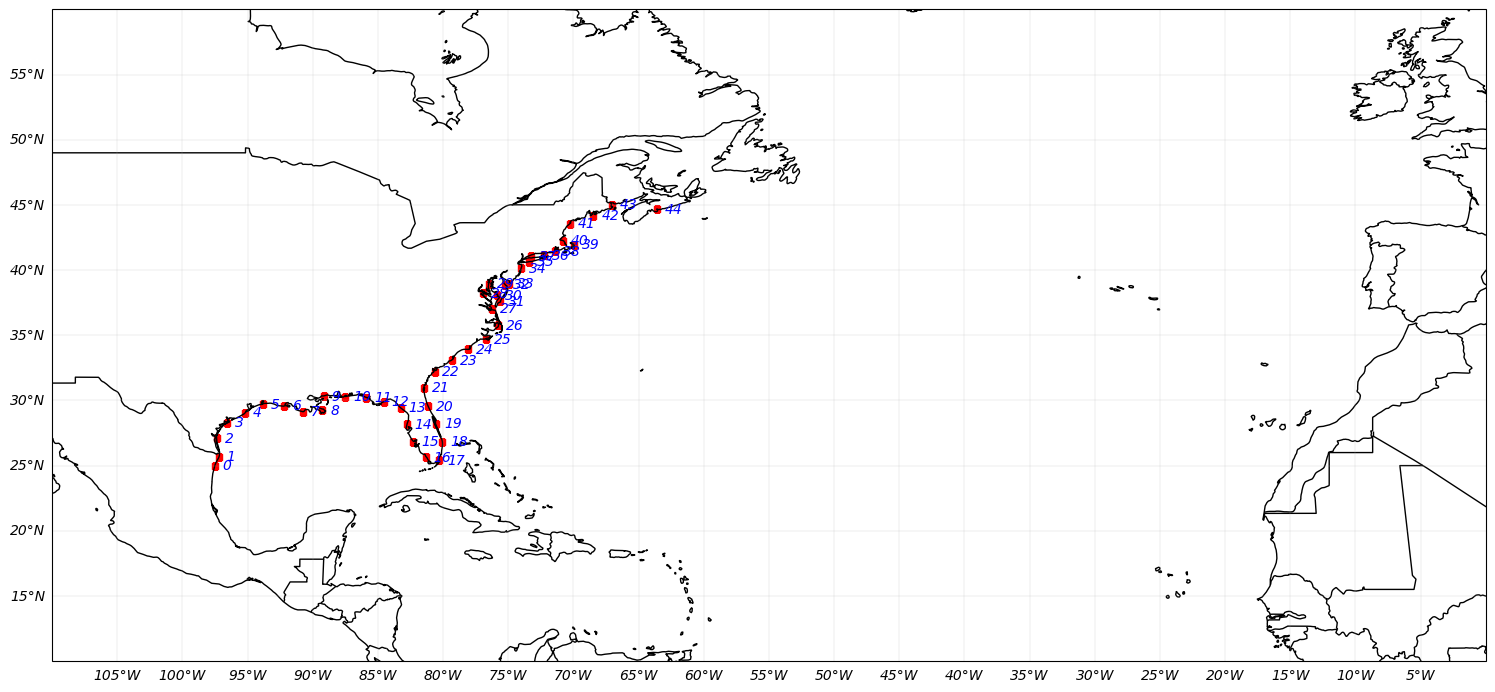

In [9]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
gl = ax.gridlines(xlocs = -long_range, ylocs = lat_range, draw_labels=True,linewidth=0.15)
gl.top_labels = False
gl.right_labels = False
ax.get_yaxis().set_ticks([])


ax.set_extent([-max_long, min_long, min_lat, max_lat], 
              crs=ccrs.PlateCarree())
              
# add our interpolated points to the Cartopy coastline
ax.scatter(points_gdf['Long'], points_gdf['Lat'], color='red', s=15, marker = 's')


for row in points_gdf.iterrows() : 
    ax.text(row[1]['Long']+0.6, row[1]['Lat']-0.3,f"{row[0]}",transform=ccrs.PlateCarree(),size = 10, color = 'b')

fig = matplotlib.pyplot.gcf()
fig.set_size_inches(18.5, 10.5)

plt.show()